# Cell 1: Project Overview

# Temporal Reference-Guided Diffusion Network (TRDN) for Video Dehazing

This notebook is the **primary execution interface** for the repository. All research logic lives in `src/`; this notebook only performs setup, configuration, visualization, debugging, and launch control for training/validation/inference.

Execution target: **VS Code notebook + Google Colab runtime**.

Core pipeline:

`REVIDE sequence -> RAFT/warping -> ConvLSTM -> Temporal Retrieval Transformer -> Reference Selection -> Temporal Conditioning Adapter -> Stable Diffusion Inpainting UNet`.


In [1]:
!cd /content/TRDN-Video-Dehazing && git pull origin main

From https://github.com/amir1373/TRDN-Video-Dehazing
 * branch            main       -> FETCH_HEAD
Already up to date.


In [2]:
# Cell 2: Install Dependencies
# Repository-first rule: install packages only; do not define model/dataset logic here.
import sys
import subprocess
from pathlib import Path

requirements_path = Path("requirements_colab.txt")
if requirements_path.exists():
    cmd = [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)]
else:
    cmd = [
        sys.executable, "-m", "pip", "install", "-q",
        "accelerate>=0.31.0", "diffusers>=0.30.0", "transformers>=4.41.0",
        "peft>=0.11.0", "tensorboard>=2.16.0", "lpips>=0.1.4",
        "torchmetrics>=1.4.0", "opencv-python>=4.8.0", "scikit-image>=0.22.0",
        "matplotlib>=3.7.0", "tqdm>=4.66.0"
    ]
print("Installing/checking dependencies...")
subprocess.check_call(cmd)
print("Dependency setup complete.")


Installing/checking dependencies...
Dependency setup complete.


In [3]:
# Cell 3: Mount Google Drive
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    COLAB = True
except Exception as exc:
    COLAB = False
    print("Google Drive mount skipped or unavailable:", repr(exc))

DRIVE_ROOT = Path("/content/drive/MyDrive") if COLAB else Path.cwd()
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print("COLAB:", COLAB)
print("DRIVE_ROOT:", DRIVE_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COLAB: True
DRIVE_ROOT: /content/drive/MyDrive


In [4]:
# Cell 4: Clone/Open Repository
# If this notebook is opened from the repo in VS Code, this cell simply locates it.
# If running directly in Colab and src/ is absent, it attempts to clone the repo.
import os
import sys
import shutil
import subprocess
from pathlib import Path

REPO_NAME = "TRDN-Video-Dehazing"
REPO_URL = "https://github.com/amir1373/TRDN-Video-Dehazing.git"

candidates = [
    Path.cwd(),
    Path.cwd().parent,
    DRIVE_ROOT / REPO_NAME,
    Path("/content") / REPO_NAME,
]
REPO_ROOT = next((p.resolve() for p in candidates if (p / "src").exists()), None)

if REPO_ROOT is None:
    clone_dir = Path("/content") / REPO_NAME if COLAB else Path.cwd() / REPO_NAME

    # Private GitHub repos need credentials in Colab. Preferred: Colab Secrets -> GITHUB_TOKEN.
    token = os.environ.get("GITHUB_TOKEN", "").strip()
    if not token:
        try:
            from google.colab import userdata
            token = (userdata.get("GITHUB_TOKEN") or "").strip()
        except Exception:
            token = ""

    clone_url = REPO_URL
    if token and REPO_URL.startswith("https://github.com/"):
        clone_url = REPO_URL.replace("https://github.com/", f"https://{token}@github.com/")

    if clone_dir.exists() and not (clone_dir / "src").exists():
        print(f"Removing incomplete clone directory: {clone_dir}")
        shutil.rmtree(clone_dir)

    print(f"src/ not found. Cloning repository into {clone_dir}...")
    result = subprocess.run(["git", "clone", clone_url, str(clone_dir)], text=True, capture_output=True)
    if result.returncode != 0:
        raise RuntimeError(
            "Could not clone/open repository. This repo is private, so Colab needs a GitHub token.\n"
            "Fix: in Colab, open the left sidebar Secrets tab, add GITHUB_TOKEN with repo read access, "
            "enable notebook access to that secret, then rerun Cell 4.\n"
            "Alternative: make the GitHub repo public or manually upload/clone the repo into Drive.\n"
            f"git stderr:\n{result.stderr}"
        )
    REPO_ROOT = clone_dir.resolve()

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("REPO_ROOT:", REPO_ROOT)
print("src exists:", (REPO_ROOT / "src").exists())


REPO_ROOT: /content/TRDN-Video-Dehazing
src exists: True


In [5]:
# Cell 5: Set Paths
# All storage paths are derived from DRIVE_ROOT and src.config.TRDNConfig.
import json
import torch
from pathlib import Path
from src.config import TRDNConfig

cfg = TRDNConfig()
cfg.project_root = str(DRIVE_ROOT / "TRDN_REVIDE")

# Central REVIDE paths. Edit here only if your Drive layout differs.
cfg.train_root = "/content/drive/MyDrive/REVIDE_sequences/Train"
cfg.test_root = "/content/drive/MyDrive/REVIDE_sequences/Test"
cfg.train_hazy = "/content/drive/MyDrive/REVIDE_sequences/Train/hazy"
cfg.test_hazy = "/content/drive/MyDrive/REVIDE_sequences/Test/hazy"
cfg.flow_train = "/content/drive/MyDrive/video_dehaze_flows/train"
cfg.flow_val = "/content/drive/MyDrive/video_dehaze_flows/val"
cfg.dataset_root = "/content/drive/MyDrive/REVIDE_sequences"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATHS = cfg.ensure_dirs()

print("DEVICE:", DEVICE)
print(json.dumps(cfg.to_dict(), indent=2, default=str))
print("Output directories:")
for name, path in PATHS.items():
    print(f"  {name}: {path}")


DEVICE: cuda
{
  "train_root": "/content/drive/MyDrive/REVIDE_sequences/Train",
  "test_root": "/content/drive/MyDrive/REVIDE_sequences/Test",
  "train_hazy": "/content/drive/MyDrive/REVIDE_sequences/Train/hazy",
  "test_hazy": "/content/drive/MyDrive/REVIDE_sequences/Test/hazy",
  "flow_train": "/content/drive/MyDrive/video_dehaze_flows/train",
  "flow_val": "/content/drive/MyDrive/video_dehaze_flows/val",
  "dataset_root": "/content/drive/MyDrive/REVIDE_sequences",
  "project_root": "/content/drive/MyDrive/TRDN_REVIDE",
  "image_size": 256,
  "crop_size": 256,
  "seq_len": 10,
  "batch_size": 1,
  "num_workers": 2,
  "mixed_precision": "fp16",
  "seed": 1234,
  "train_mode": "reconstruct",
  "train_split": "train",
  "val_split": "val",
  "image_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
  ],
  "sd_model_id": "runwayml/stable-diffusion-inpainting",
  "use_raft_alignment": true,
  "freeze_raft": true,
  "use_temporal_transformer": true,
  "

In [6]:
from pathlib import Path
import json

ckpt_dir = PATHS["checkpoints"]
checkpoints = sorted([p for p in ckpt_dir.iterdir() if p.is_dir()])

print("Checkpoint directory:", ckpt_dir)
print("Found checkpoints:")
for p in checkpoints:
    meta = p / "metadata.json"
    if meta.exists():
        data = json.loads(meta.read_text())
        print(p.name, "step=", data.get("step"), "best_psnr=", data.get("best_psnr"), "best_ssim=", data.get("best_ssim"))
    else:
        print(p.name, "(no metadata)")

latest = checkpoints[-1] if checkpoints else None
print("\nLatest checkpoint:", latest)

Checkpoint directory: /content/drive/MyDrive/TRDN_REVIDE/checkpoints
Found checkpoints:
best_psnr step= 2100 best_psnr= 30.263810449794136 best_ssim= 0.7335871113144503
best_ssim step= 2100 best_psnr= 30.263810449794136 best_ssim= 0.737818024535238
step_000250 step= 250 best_psnr= 27.926283576791295 best_ssim= 0.6894054337459812
step_000500 step= 500 best_psnr= 27.926283576791295 best_ssim= 0.6960251330199012
step_000750 step= 750 best_psnr= 28.12102824155835 best_ssim= 0.6960251330199012
step_001000 step= 1000 best_psnr= 29.32768483313815 best_ssim= 0.7201777626279058
step_001250 step= 1250 best_psnr= 29.7176717680855 best_ssim= 0.7215888349023594
step_001500 step= 1500 best_psnr= 29.7176717680855 best_ssim= 0.7215888349023594
step_001750 step= 1750 best_psnr= 29.7176717680855 best_ssim= 0.7228264109644926
step_002000 step= 2000 best_psnr= 29.74232531109852 best_ssim= 0.7335871113144503
step_002250 step= 2250 best_psnr= 30.263810449794136 best_ssim= 0.737818024535238
step_002500 step=

In [7]:
# Cell 6: Imports from src/
# This cell imports repository modules. It intentionally contains no core implementations.
import json
import subprocess
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from accelerate.utils import set_seed

from src.dataset import discover_revide_sequences
from src.masks import generate_haze_mask
from src.flow import flow_to_rgb
from src.diffusion_adapter import load_diffusion_backbone
from src.losses import LossBundle
from src.train import build_temporal_modules, dry_run_shape_test, train_trdn
from src.validate import validate_trdn
from src.inference import run_inference_on_index
from src.notebook_utils import get_sample_batch, make_dataset, run_temporal_debug, show_tensor_images

set_seed(cfg.seed)
print("Repository imports ready. Notebook helpers are imported from src.notebook_utils.")


Repository imports ready. Notebook helpers are imported from src.notebook_utils.


In [7]:
# Cell 7: Dataset Inspection
train_sequences = discover_revide_sequences(Path(cfg.train_root), split=None, extensions=cfg.image_extensions)
test_sequences = discover_revide_sequences(Path(cfg.test_root), split=None, extensions=cfg.image_extensions)
print("TRAIN_ROOT:", cfg.train_root, "exists:", Path(cfg.train_root).exists(), "sequences:", len(train_sequences))
print("TEST_ROOT:", cfg.test_root, "exists:", Path(cfg.test_root).exists(), "sequences:", len(test_sequences))

train_dataset, sample, batch = get_sample_batch(cfg, DEVICE, split="train")
print("Dataset length:", len(train_dataset), "sequence:", sample["sequence_name"], "mode:", sample["train_mode"])
for key in ["frames", "current_frame", "target_frame", "mask", "corrupted_frame", "warped_references"]:
    value = sample[key]
    print(f"{key}: shape={tuple(value.shape)} dtype={value.dtype} min={float(value.min()):.4f} max={float(value.max()):.4f}")


TRAIN_ROOT: /content/drive/MyDrive/REVIDE_sequences/Train exists: True sequences: 1319
TEST_ROOT: /content/drive/MyDrive/REVIDE_sequences/Test exists: True sequences: 230


KeyboardInterrupt: 

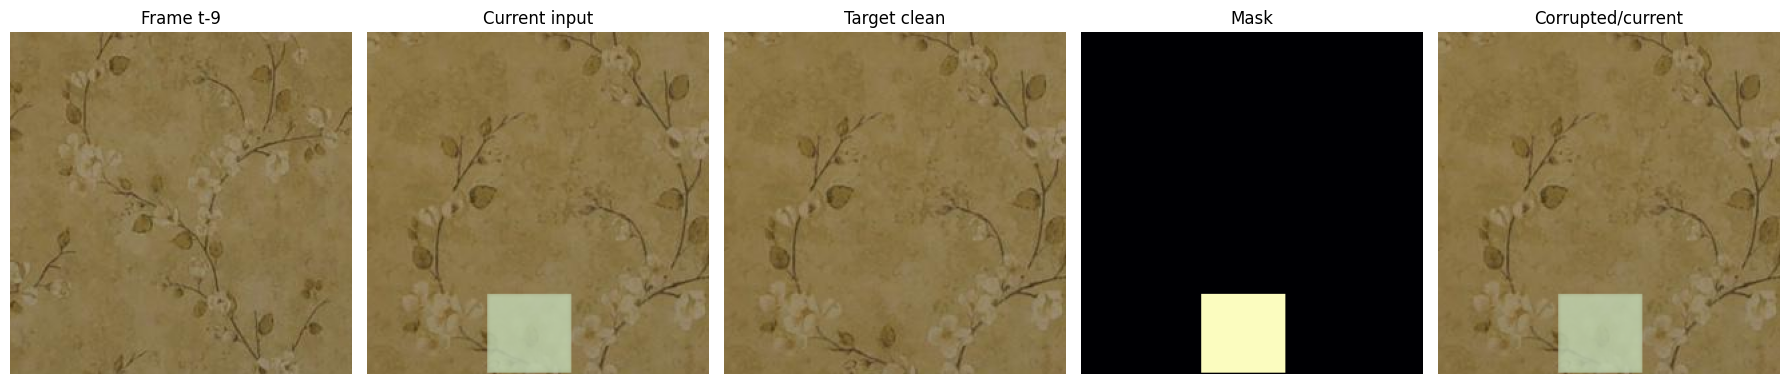

In [7]:
# Cell 8: Dataset Visualization
_, sample, batch = get_sample_batch(cfg, DEVICE, split="train")
show_tensor_images(
    [sample["frames"][0], sample["frames"][-1], sample["target_frame"], sample["mask"], sample["corrupted_frame"]],
    ["Frame t-9", "Current input", "Target clean", "Mask", "Corrupted/current"],
    figsize=(18, 4),
    save_path=PATHS["visualizations"] / "dataset_visualization.png",
)


/content/TRDN-Video-Dehazing/src/temporal_transformer.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


frames: (1, 10, 3, 256, 256)
warped_refs: (1, 9, 3, 256, 256)
flows: (1, 9, 2, 256, 256)


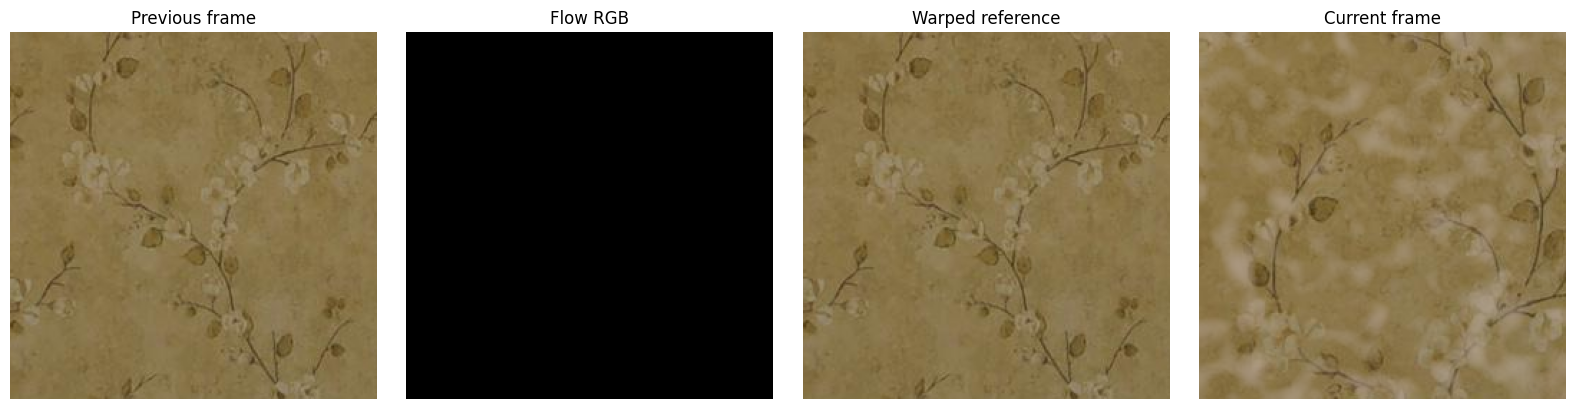

In [8]:
# Cell 9: Flow Visualization
# Default is zero-flow for Restart + Run All speed. Set RUN_RAFT_FLOW_VIS=True for RAFT on GPU.
RUN_RAFT_FLOW_VIS = False
_, sample, batch = get_sample_batch(cfg, DEVICE, split="train")
debug = run_temporal_debug(cfg, batch, DEVICE, use_raft=RUN_RAFT_FLOW_VIS)
print("frames:", tuple(debug["frames"].shape))
print("warped_refs:", tuple(debug["warped_refs"].shape))
print("flows:", tuple(debug["flows"].shape))
show_tensor_images(
    [debug["frames"][0, 0].cpu(), flow_to_rgb(debug["flows"][0, 0].cpu()), debug["warped_refs"][0, 0].cpu(), debug["frames"][0, -1].cpu()],
    ["Previous frame", "Flow RGB", "Warped reference", "Current frame"],
    figsize=(16, 4),
    save_path=PATHS["visualizations"] / "flow_visualization.png",
)


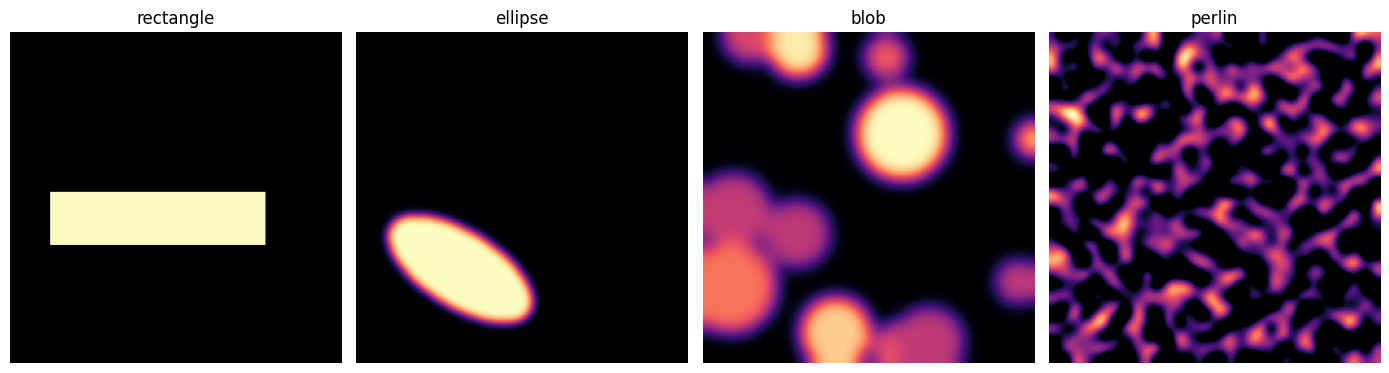

In [9]:
# Cell 10: Mask Visualization
modes = ["rectangle", "ellipse", "blob", "perlin"]
masks = [generate_haze_mask(cfg.image_size, cfg.image_size, mode) for mode in modes]
show_tensor_images(masks, modes, figsize=(14, 4), save_path=PATHS["visualizations"] / "mask_visualization.png")


In [8]:
# Cell 11: Debug Forward Pass
# Calls repository script. Default skips RAFT and Stable Diffusion for Restart + Run All compatibility.
RUN_FULL_DEBUG_FORWARD = False
cmd = [sys.executable, "debug_forward_pass.py"]
if not RUN_FULL_DEBUG_FORWARD:
    cmd += ["--skip-diffusion", "--no-raft"]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(REPO_ROOT), text=True, capture_output=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("debug_forward_pass.py failed")
report_path = Path(cfg.project_root) / "debug_outputs" / "debug_report.json"
if not report_path.exists():
    report_path = REPO_ROOT / "debug_outputs" / "debug_report.json"
if report_path.exists():
    print("Debug report:")
    print(report_path.read_text(encoding="utf-8"))
else:
    print("Debug report was not found; check debug script output above.")


Running: /usr/bin/python3 debug_forward_pass.py --skip-diffusion --no-raft
{
  "train_mode": "reconstruct",
  "dataset_root_used": "/content/drive/MyDrive/REVIDE_sequences/Train",
  "sequence_name": "E004_seq_014",
  "shapes": {
    "frames": [
      1,
      10,
      3,
      256,
      256
    ],
    "target": [
      1,
      3,
      256,
      256
    ],
    "mask": [
      1,
      1,
      256,
      256
    ],
    "warped_references": [
      1,
      9,
      3,
      256,
      256
    ],
    "flows": [
      1,
      9,
      2,
      256,
      256
    ],
    "temporal_memory": [
      1,
      64,
      256,
      256
    ],
    "transformer_tokens": [
      1,
      640,
      256
    ],
    "transformer_token_importance": [
      1,
      10,
      8,
      8
    ],
    "reference_weights": [
      1,
      9,
      256,
      256
    ],
    "conditioning_tokens": [
      1,
      16,
      768
    ]
  },
  "parameters": {
    "temporal_memory": {
      "total": 371200,

In [9]:
# Cell 12: Training Configuration
# Edit these controls. Run-all leaves heavy training disabled.
cfg.train_mode = "reconstruct"  # "reconstruct" or "dehaze"
cfg.image_size = 256
cfg.crop_size = 256
cfg.seq_len = 10
cfg.batch_size = 1
cfg.num_workers = 2
cfg.mixed_precision = "fp16"
cfg.use_raft_alignment = True
cfg.use_temporal_transformer = True
cfg.enable_lora = False
cfg.enable_torch_compile = False
cfg.max_train_steps = 0  # 0 = train for all 15 epochs; set a positive number to cap steps.
cfg.num_epochs = 15
AUTO_RESUME_LATEST = True
if AUTO_RESUME_LATEST:
    checkpoint_dir = PATHS["checkpoints"]
    existing_checkpoints = sorted([p for p in checkpoint_dir.iterdir() if p.is_dir()]) if checkpoint_dir.exists() else []
    cfg.resume_from_checkpoint = str(existing_checkpoints[-1]) if existing_checkpoints else ""
else:
    cfg.resume_from_checkpoint = ""

RUN_TRAINING = False  # Change to True, then run Cell 13 to start training.
print(json.dumps(cfg.to_dict(), indent=2, default=str))
print("RUN_TRAINING:", RUN_TRAINING)
print("Training schedule: 15 epochs; tqdm progress comes from src.train.train_trdn().")
print("Resume checkpoint:", cfg.resume_from_checkpoint or "none")


{
  "train_root": "/content/drive/MyDrive/REVIDE_sequences/Train",
  "test_root": "/content/drive/MyDrive/REVIDE_sequences/Test",
  "train_hazy": "/content/drive/MyDrive/REVIDE_sequences/Train/hazy",
  "test_hazy": "/content/drive/MyDrive/REVIDE_sequences/Test/hazy",
  "flow_train": "/content/drive/MyDrive/video_dehaze_flows/train",
  "flow_val": "/content/drive/MyDrive/video_dehaze_flows/val",
  "dataset_root": "/content/drive/MyDrive/REVIDE_sequences",
  "project_root": "/content/drive/MyDrive/TRDN_REVIDE",
  "image_size": 256,
  "crop_size": 256,
  "seq_len": 10,
  "batch_size": 1,
  "num_workers": 2,
  "mixed_precision": "fp16",
  "seed": 1234,
  "train_mode": "reconstruct",
  "train_split": "train",
  "val_split": "val",
  "image_extensions": [
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
  ],
  "sd_model_id": "runwayml/stable-diffusion-inpainting",
  "use_raft_alignment": true,
  "freeze_raft": true,
  "use_temporal_transformer": true,
  "transformer_n

In [10]:
cfg.resume_from_checkpoint = "/content/drive/MyDrive/TRDN_REVIDE/checkpoints/step_002500"
RUN_TRAINING = True

In [ ]:
# Cell 13: Training Launch
if RUN_TRAINING:
    training_result = train_trdn(cfg)
    print("Training result:", training_result)
else:
    print("Training skipped for Restart + Run All. Set RUN_TRAINING=True in Cell 12 to launch.")
    print("Checkpoints:", PATHS["checkpoints"])
    print("Logs:", PATHS["logs"])


In [14]:
cfg.resume_from_checkpoint = "/content/drive/MyDrive/TRDN_REVIDE/checkpoints/best_ssim"

In [19]:
# Cell 14: Validation
# Heavy validation is disabled by default. It uses src.validate.validate_trdn when enabled.
RUN_VALIDATION = True
VALIDATION_CHECKPOINT = cfg.resume_from_checkpoint
if RUN_VALIDATION:
    diffusion = load_diffusion_backbone(cfg, DEVICE)
    temporal_memory, temporal_transformer, reference_selector, conditioning_adapter = build_temporal_modules(
        cfg, diffusion["unet"].config.cross_attention_dim, DEVICE
    )
    val_loader = DataLoader(make_dataset(cfg, split="test", random_crop=False), batch_size=1, shuffle=False, num_workers=0)
    loss_bundle = LossBundle(device=DEVICE)
    metrics = validate_trdn(
        val_loader,
        diffusion,
        temporal_memory,
        temporal_transformer,
        reference_selector,
        conditioning_adapter,
        loss_bundle,
        DEVICE,
        raft_model=None,
        max_batches=4,
        num_steps=min(10, cfg.num_inference_steps),
    )
    print({key: value for key, value in metrics.items() if isinstance(value, float)})
else:
    print("Validation skipped. Set RUN_VALIDATION=True after training or loading a checkpoint.")


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Validation:   0%|          | 0/230 [00:00<?, ?it/s]

DDIM inference:   0%|          | 0/10 [00:00<?, ?it/s]

DDIM inference:   0%|          | 0/10 [00:00<?, ?it/s]

DDIM inference:   0%|          | 0/10 [00:00<?, ?it/s]

DDIM inference:   0%|          | 0/10 [00:00<?, ?it/s]

{'psnr': 18.596248431991306, 'ssim': 0.6567354556236817, 'lpips': 0.2508825846016407}


In [21]:
# Cell 15: Inference
# Heavy inference is disabled by default. It uses src.inference.run_inference_on_index when enabled.
RUN_INFERENCE = True
INFERENCE_CHECKPOINT = cfg.resume_from_checkpoint
if RUN_INFERENCE:
    output = run_inference_on_index(cfg, index=0, checkpoint_path=INFERENCE_CHECKPOINT)
    print("Saved prediction:", output["save_path"])
else:
    print("Inference skipped. Set RUN_INFERENCE=True and provide INFERENCE_CHECKPOINT if needed.")


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch runwayml/stable-diffusion-inpainting: runwayml/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


ValueError: could not determine the shape of object type 'torch.storage.UntypedStorage'

In [ ]:
# Cell 16: Attention Visualization
# Visualizes transformer token-importance maps returned by src.temporal_transformer.
_, sample, batch = get_sample_batch(cfg, DEVICE, split="train")
debug = run_temporal_debug(cfg, batch, DEVICE, use_raft=False)
importance = debug["transformer"]["token_importance"][0]
current_importance = importance[-1:].cpu()
current_importance = (current_importance - current_importance.min()) / (current_importance.max() - current_importance.min() + 1e-8)
show_tensor_images(
    [current_importance],
    ["Current-frame transformer token importance"],
    figsize=(5, 5),
    save_path=PATHS["visualizations"] / "attention_visualization.png",
)
print("transformer tokens:", tuple(debug["transformer"]["tokens"].shape))
print("conditioning tokens:", tuple(debug["conditioning_tokens"].shape))


In [ ]:
# Cell 17: Reference Weight Visualization
_, sample, batch = get_sample_batch(cfg, DEVICE, split="train")
debug = run_temporal_debug(cfg, batch, DEVICE, use_raft=False)
weights = debug["reference"]["weights"][0]
num_show = min(5, weights.shape[0])
show_tensor_images(
    [weights[i:i+1].cpu() for i in range(num_show)] + [debug["reference"]["weighted_reference"][0].cpu()],
    [f"Ref {i} weight" for i in range(num_show)] + ["Weighted reference"],
    figsize=(18, 4),
    save_path=PATHS["visualizations"] / "reference_weight_visualization.png",
)
print("reference weights:", tuple(debug["reference"]["weights"].shape))


In [ ]:
# Cell 18: Checkpoint Management
checkpoint_dir = PATHS["checkpoints"]
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoints = sorted([p for p in checkpoint_dir.iterdir() if p.is_dir()])
print("Checkpoint directory:", checkpoint_dir)
if checkpoints:
    print("Available checkpoints:")
    for p in checkpoints[-10:]:
        print(" -", p)
    cfg.resume_from_checkpoint = str(checkpoints[-1])
    print("Default resume_from_checkpoint set to:", cfg.resume_from_checkpoint)
else:
    print("No checkpoints found yet.")
print("TensorBoard logs:", PATHS["logs"])
print("Colab TensorBoard command: %load_ext tensorboard ; %tensorboard --logdir", PATHS["logs"])
